<a href="https://colab.research.google.com/github/jwookkim0512/machinelearning-assignments/blob/main/11%EC%A3%BC%EC%B0%A8_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Instructions for updating:

Future major versions of TensorFlow will allow gradients to flow
into the labels input on backprop by default.

See `tf.nn.softmax_cross_entropy_with_logits_v2`.



Iter : 0
Train Loss : 2.7008590698242188
Cost : 2.780416488647461
Iter : 250
Train Loss : 0.5358250141143799
Cost : 0.5355867147445679
Iter : 500
Train Loss : 0.2304883599281311
Cost : 0.12499162554740906
Iter : 750
Train Loss : 0.21443727612495422
Cost : 0.1808595210313797
Iter : 1000
Train Loss : 0.1482425183057785
Cost : 0.14667686820030212
Iter : 1250
Train Loss : 0.15902243554592133
Cost : 0.08615954220294952
Iter : 1500
Train Loss : 0.08915922045707703
Cost : 0.08747980743646622
Iter : 1750
Train Loss : 0.06294190883636475
Cost : 0.06464293599128723
Iter : 2000
Train Loss : 0.15387257933616638
Cost : 0.23162302374839783
Iter : 2250
Train Loss : 0.10424847900867462
Cost : 0.0938195213675499


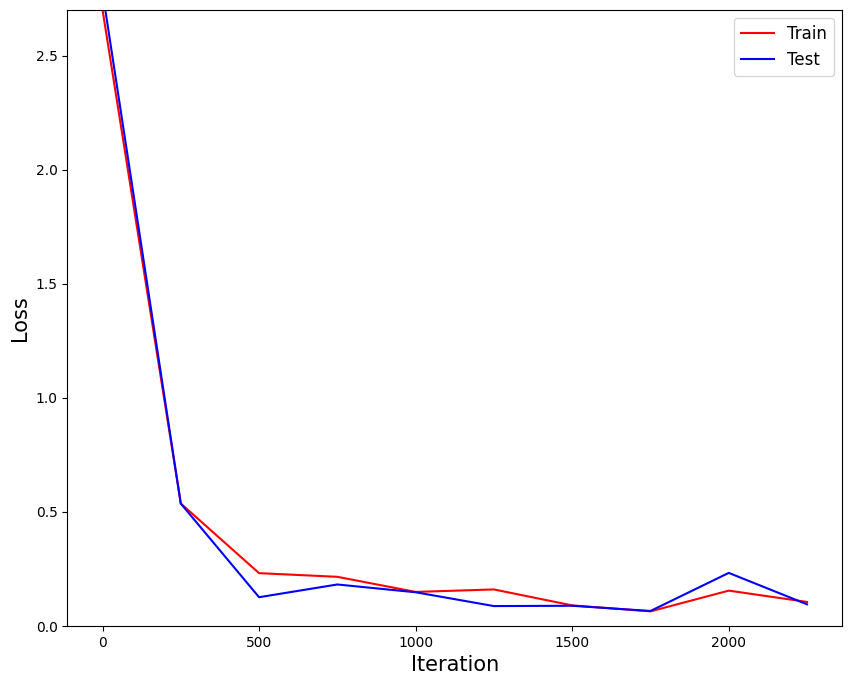

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# MNIST 데이터셋 로딩
mnist = tf.keras.datasets.mnist
(train_x, train_y), (test_x, test_y) = mnist.load_data()

# 픽셀 값을 0~1 범위로 정규화
train_x, test_x = train_x / 255.0, test_x / 255.0


# Reshape the data for CNN input (batch, height, width, channels)
train_x = train_x.reshape((train_x.shape[0], 28, 28, 1))
test_x = test_x.reshape((test_x.shape[0], 28, 28, 1))

# input layer
input_h = 28               # input height
input_w = 28               # input width
input_ch = 1               # input channel (Grayscale)

# 1st convolution layer
k1_h = 3                   # kernel height
k1_w = 3                   # kernel width
k1_ch = 32                 # output channels (filters)
p1_h = 2                   # pool height
p1_w = 2                   # pool width
# output shape after pool: (None, 14, 14, 32)

# 2nd convolution layer
k2_h = 3
k2_w = 3
k2_ch = 64
p2_h = 2
p2_w = 2
# output shape after pool: (None, 7, 7, 64)

# Fully connected layer input size: flatten the features
conv_result_size = 7 * 7 * 64

n_hidden = 100             # hidden layer units
n_output = 10              # MNIST: 10 classes (0~9)


# Kernel size : [kernel_height, kernel_width, input_ch, output_ch]
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

weights = {
    'conv1': tf.Variable(tf.random.normal([3, 3, 1, 32], stddev=0.1)),     # 3x3 커널, 입력채널 1, 출력채널 32
    'conv2': tf.Variable(tf.random.normal([3, 3, 32, 64], stddev=0.1)),    # 3x3 커널, 입력채널 32, 출력채널 64
    'hidden': tf.Variable(tf.random.normal([5 * 5 * 64, 100], stddev=0.1)),# conv2 결과를 flatten한 후 100개의 노드
    'output': tf.Variable(tf.random.normal([100, 10], stddev=0.1))         # hidden → output layer (10 classes)
}

biases = {
    'conv1': tf.Variable(tf.random.normal([32], stddev=0.1)),   # conv1 출력 채널 수
    'conv2': tf.Variable(tf.random.normal([64], stddev=0.1)),   # conv2 출력 채널 수
    'hidden': tf.Variable(tf.random.normal([100], stddev=0.1)), # hidden layer 노드 수
    'output': tf.Variable(tf.random.normal([10], stddev=0.1))   # output layer 클래스 수
}
x = tf.placeholder(shape=[None, input_h, input_w, input_ch], dtype=tf.float32)
y = tf.placeholder(shape=[None, n_output], dtype=tf.float32)

def net(x, weights, biases):
    # 1st convolution layer: VALID padding
    conv1 = tf.nn.conv2d(x, weights['conv1'], strides=[1, 1, 1, 1], padding='VALID')     #교수님 깃허브에 valid로 표시한 주석이 있어서 valid로
    conv1 = tf.nn.relu(tf.add(conv1, biases['conv1']))
    maxp1 = tf.nn.max_pool(conv1, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='VALID')

    # 2nd convolution layer: VALID padding
    conv2 = tf.nn.conv2d(maxp1, weights['conv2'], strides=[1, 1, 1, 1], padding='VALID')
    conv2 = tf.nn.relu(tf.add(conv2, biases['conv2']))
    maxp2 = tf.nn.max_pool(conv2, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='VALID')

    # flatten for fully connected layer
    maxp2_flatten = tf.reshape(maxp2, [-1, 5 * 5 * 64])  # 5x5x64 = 1600

    # Fully connected layer
    hidden = tf.add(tf.matmul(maxp2_flatten, weights['hidden']), biases['hidden'])
    hidden = tf.nn.relu(hidden)

    # Output layer
    output = tf.add(tf.matmul(hidden, weights['output']), biases['output'])

    return output

LR = 0.0001
pred = net(x, weights, biases)
loss = tf.nn.softmax_cross_entropy_with_logits(logits=pred, labels=y)           #내부적으로 계산 후 비교 y는 one hot vector
loss = tf.reduce_mean(loss)

optm = tf.train.AdamOptimizer(learning_rate=LR).minimize(loss)


n_batch = 50
n_iter = 2500
n_prt = 250

sess = tf.Session()
sess.run(tf.global_variables_initializer())

loss_record_train = []
loss_record_test = []
for epoch in range(n_iter):
    # train_x, train_y = mnist.train.next_batch(n_batch)
    # train_x = np.reshape(train_x, (-1, 28, 28, 1))
    # # train_x = np.reshape(train_x, (n_batch, input_h, input_w, input_ch))
    # sess.run(optm, feed_dict={x:train_x, y:train_y})

    # Get a random batch of training data
    batch_indices = np.random.choice(train_x.shape[0], size=n_batch, replace=False)
    batch_x = train_x[batch_indices]
    batch_y = train_y[batch_indices]

    batch_x = np.reshape(batch_x, (-1, 28, 28, 1))
    # batch_x = np.reshape(batch_x, (n_batch, input_h, input_w, input_ch))
    # Convert labels to one-hot encoding if necessary
    batch_y = tf.keras.utils.to_categorical(batch_y, num_classes=10)  # Adjust num_classes if needed

    sess.run(optm, feed_dict={x:batch_x, y:batch_y})

    if epoch % n_prt == 0:
        # test_x, test_y = mnist.test.next_batch(n_batch)
        # test_x = test_x.reshape((n_batch, input_h, input_w, input_ch))
        # c1 = sess.run(loss, feed_dict={x:train_x, y:train_y})
        # c2 = sess.run(loss, feed_dict={x:test_x, y:test_y})

        # Get a random batch of test data
        test_batch_indices = np.random.choice(test_x.shape[0], size=n_batch, replace=False)
        test_batch_x = test_x[test_batch_indices]
        test_batch_y = test_y[test_batch_indices]

        test_batch_x = test_batch_x.reshape((n_batch, input_h, input_w, input_ch))
        # Convert labels to one-hot encoding if necessary
        test_batch_y = tf.keras.utils.to_categorical(test_batch_y, num_classes=10)  # Adjust num_classes if needed
        c1 = sess.run(loss, feed_dict={x: batch_x, y: batch_y})
        c2 = sess.run(loss, feed_dict={x: test_batch_x, y: test_batch_y})

        loss_record_train.append(c1)
        loss_record_test.append(c2)
        print("Iter : {}".format(epoch))
        print("Train Loss : {}".format(c1))
        print("Cost : {}".format(c2))

plt.figure(figsize = (10,8))
plt.plot(np.arange(len(loss_record_train))*n_prt, loss_record_train, 'r', label = 'Train')
plt.plot(np.arange(len(loss_record_test))*n_prt, loss_record_test, 'b', label = 'Test')
plt.xlabel('Iteration', fontsize = 15)
plt.ylabel('Loss', fontsize = 15)
plt.legend(fontsize = 12)
plt.ylim([0, np.max(loss_record_train)])
plt.show()

입력: 28×28

Conv1 (3×3, VALID) → 26×26

Pool1 (2×2) → 13×13

Conv2 (3×3, VALID) → 11×11

Pool2 (2×2) → 5×5

Iter : 0
Train Loss : 2.4194231033325195
Cost : 2.4160866737365723
Iter : 250
Train Loss : 0.626132607460022
Cost : 0.49379265308380127
Iter : 500
Train Loss : 0.49877819418907166
Cost : 0.1688808798789978
Iter : 750
Train Loss : 0.4112376272678375
Cost : 0.15852585434913635
Iter : 1000
Train Loss : 0.1354748010635376
Cost : 0.2092120200395584
Iter : 1250
Train Loss : 0.24803361296653748
Cost : 0.11581484973430634
Iter : 1500
Train Loss : 0.11738870292901993
Cost : 0.18010416626930237
Iter : 1750
Train Loss : 0.051505912095308304
Cost : 0.1431398093700409
Iter : 2000
Train Loss : 0.05388990044593811
Cost : 0.02644614689052105
Iter : 2250
Train Loss : 0.22562062740325928
Cost : 0.06269410252571106


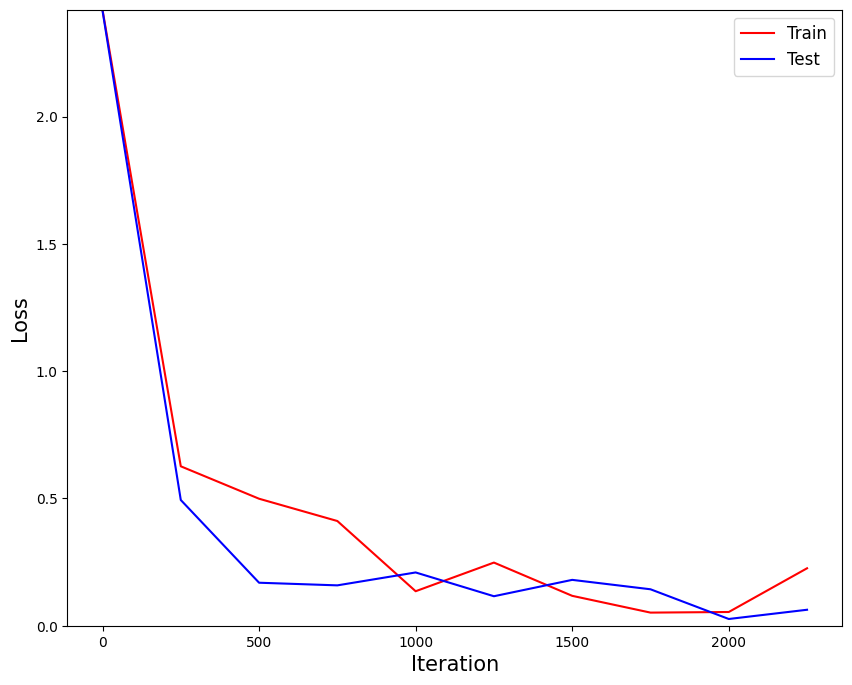

In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# MNIST 데이터셋 로딩
mnist = tf.keras.datasets.mnist
(train_x, train_y), (test_x, test_y) = mnist.load_data()

# 픽셀 값을 0~1 범위로 정규화
train_x, test_x = train_x / 255.0, test_x / 255.0


# Reshape the data for CNN input (batch, height, width, channels)
train_x = train_x.reshape((train_x.shape[0], 28, 28, 1))
test_x = test_x.reshape((test_x.shape[0], 28, 28, 1))

# input layer
input_h = 28               # input height
input_w = 28               # input width
input_ch = 1               # input channel (Grayscale)

# 1st convolution layer
k1_h = 3                   # kernel height
k1_w = 3                   # kernel width
k1_ch = 32                 # output channels (filters)
p1_h = 2                   # pool height
p1_w = 2                   # pool width
# output shape after pool: (None, 14, 14, 32)

# 2nd convolution layer
k2_h = 3
k2_w = 3
k2_ch = 64
p2_h = 2
p2_w = 2
# output shape after pool: (None, 7, 7, 64)

# Fully connected layer input size: flatten the features
conv_result_size = 7 * 7 * 64

n_hidden = 100             # hidden layer units
n_output = 10              # MNIST: 10 classes (0~9)


# Kernel size : [kernel_height, kernel_width, input_ch, output_ch]
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

weights = {
    'conv1': tf.Variable(tf.random.normal([3, 3, 1, 32], stddev=0.1)),     # 3x3 커널, 입력채널 1, 출력채널 32
    'conv2': tf.Variable(tf.random.normal([3, 3, 32, 64], stddev=0.1)),    # 3x3 커널, 입력채널 32, 출력채널 64
    'hidden': tf.Variable(tf.random.normal([7 * 7 * 64, 100], stddev=0.1)),# conv2 결과를 flatten한 후 100개의 노드
    'output': tf.Variable(tf.random.normal([100, 10], stddev=0.1))         # hidden → output layer (10 classes)
}

biases = {
    'conv1': tf.Variable(tf.random.normal([32], stddev=0.1)),   # conv1 출력 채널 수
    'conv2': tf.Variable(tf.random.normal([64], stddev=0.1)),   # conv2 출력 채널 수
    'hidden': tf.Variable(tf.random.normal([100], stddev=0.1)), # hidden layer 노드 수
    'output': tf.Variable(tf.random.normal([10], stddev=0.1))   # output layer 클래스 수
}
x = tf.placeholder(shape=[None, input_h, input_w, input_ch], dtype=tf.float32)
y = tf.placeholder(shape=[None, n_output], dtype=tf.float32)

def net(x, weights, biases):
    # 1st convolution layer: SAME padding
    conv1 = tf.nn.conv2d(x, weights['conv1'], strides=[1, 1, 1, 1], padding='SAME')
    conv1 = tf.nn.relu(tf.add(conv1, biases['conv1']))
    maxp1 = tf.nn.max_pool(conv1, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='SAME')

    # 2nd convolution layer: SAME padding
    conv2 = tf.nn.conv2d(maxp1, weights['conv2'], strides=[1, 1, 1, 1], padding='SAME')
    conv2 = tf.nn.relu(tf.add(conv2, biases['conv2']))
    maxp2 = tf.nn.max_pool(conv2, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='SAME')

    # flatten for fully connected layer
    maxp2_flatten = tf.reshape(maxp2, [-1, 7 * 7 * 64])  # SAME이면 출력 shape = (7, 7, 64)

    # Fully connected layer
    hidden = tf.add(tf.matmul(maxp2_flatten, weights['hidden']), biases['hidden'])
    hidden = tf.nn.relu(hidden)

    # Output layer
    output = tf.add(tf.matmul(hidden, weights['output']), biases['output'])

    return output


LR = 0.0001
pred = net(x, weights, biases)
loss = tf.nn.softmax_cross_entropy_with_logits(logits=pred, labels=y)           #내부적으로 계산 후 비교 y는 one hot vector
loss = tf.reduce_mean(loss)

optm = tf.train.AdamOptimizer(learning_rate=LR).minimize(loss)


n_batch = 50
n_iter = 2500
n_prt = 250

sess = tf.Session()
sess.run(tf.global_variables_initializer())

loss_record_train = []
loss_record_test = []
for epoch in range(n_iter):
    # train_x, train_y = mnist.train.next_batch(n_batch)
    # train_x = np.reshape(train_x, (-1, 28, 28, 1))
    # # train_x = np.reshape(train_x, (n_batch, input_h, input_w, input_ch))
    # sess.run(optm, feed_dict={x:train_x, y:train_y})

    # Get a random batch of training data
    batch_indices = np.random.choice(train_x.shape[0], size=n_batch, replace=False)
    batch_x = train_x[batch_indices]
    batch_y = train_y[batch_indices]

    batch_x = np.reshape(batch_x, (-1, 28, 28, 1))
    # batch_x = np.reshape(batch_x, (n_batch, input_h, input_w, input_ch))
    # Convert labels to one-hot encoding if necessary
    batch_y = tf.keras.utils.to_categorical(batch_y, num_classes=10)  # Adjust num_classes if needed

    sess.run(optm, feed_dict={x:batch_x, y:batch_y})

    if epoch % n_prt == 0:
        # test_x, test_y = mnist.test.next_batch(n_batch)
        # test_x = test_x.reshape((n_batch, input_h, input_w, input_ch))
        # c1 = sess.run(loss, feed_dict={x:train_x, y:train_y})
        # c2 = sess.run(loss, feed_dict={x:test_x, y:test_y})

        # Get a random batch of test data
        test_batch_indices = np.random.choice(test_x.shape[0], size=n_batch, replace=False)
        test_batch_x = test_x[test_batch_indices]
        test_batch_y = test_y[test_batch_indices]

        test_batch_x = test_batch_x.reshape((n_batch, input_h, input_w, input_ch))
        # Convert labels to one-hot encoding if necessary
        test_batch_y = tf.keras.utils.to_categorical(test_batch_y, num_classes=10)  # Adjust num_classes if needed
        c1 = sess.run(loss, feed_dict={x: batch_x, y: batch_y})
        c2 = sess.run(loss, feed_dict={x: test_batch_x, y: test_batch_y})

        loss_record_train.append(c1)
        loss_record_test.append(c2)
        print("Iter : {}".format(epoch))
        print("Train Loss : {}".format(c1))
        print("Cost : {}".format(c2))

plt.figure(figsize = (10,8))
plt.plot(np.arange(len(loss_record_train))*n_prt, loss_record_train, 'r', label = 'Train')
plt.plot(np.arange(len(loss_record_test))*n_prt, loss_record_test, 'b', label = 'Test')
plt.xlabel('Iteration', fontsize = 15)
plt.ylabel('Loss', fontsize = 15)
plt.legend(fontsize = 12)
plt.ylim([0, np.max(loss_record_train)])
plt.show()

same 버젼


Iter : 0
Train Loss : 2.384645700454712
Cost : 2.3763434886932373
Iter : 250
Train Loss : 0.7091491222381592
Cost : 0.4759560525417328
Iter : 500
Train Loss : 0.33871546387672424
Cost : 0.31188857555389404
Iter : 750
Train Loss : 0.39484405517578125
Cost : 0.29123544692993164
Iter : 1000
Train Loss : 0.2269672155380249
Cost : 0.11665242165327072
Iter : 1250
Train Loss : 0.14892159402370453
Cost : 0.17545150220394135
Iter : 1500
Train Loss : 0.15313297510147095
Cost : 0.0867544487118721
Iter : 1750
Train Loss : 0.09661012887954712
Cost : 0.12034869939088821
Iter : 2000
Train Loss : 0.08464373648166656
Cost : 0.10542573779821396
Iter : 2250
Train Loss : 0.0333343967795372
Cost : 0.04842706769704819


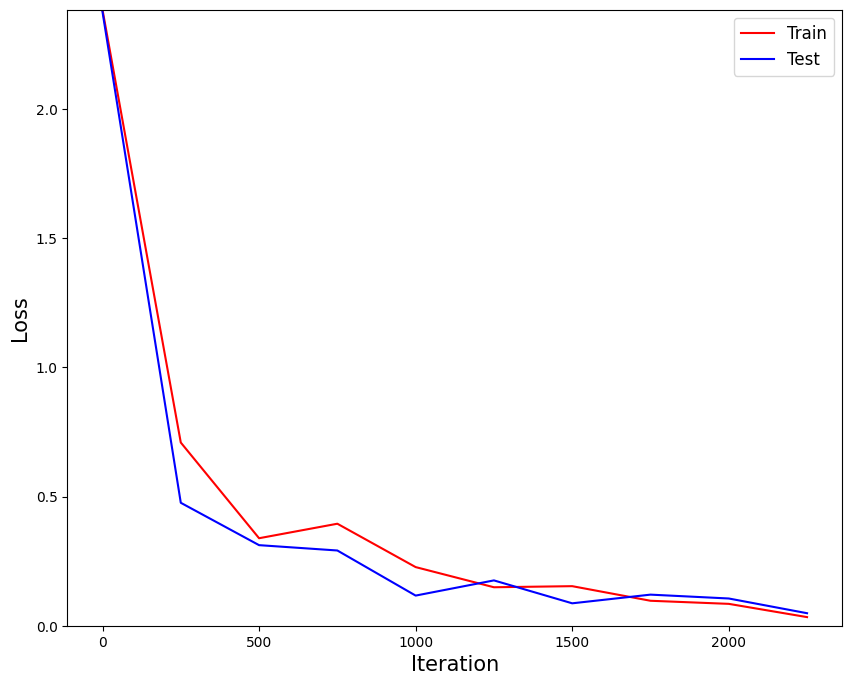

Accuracy : 100.0%


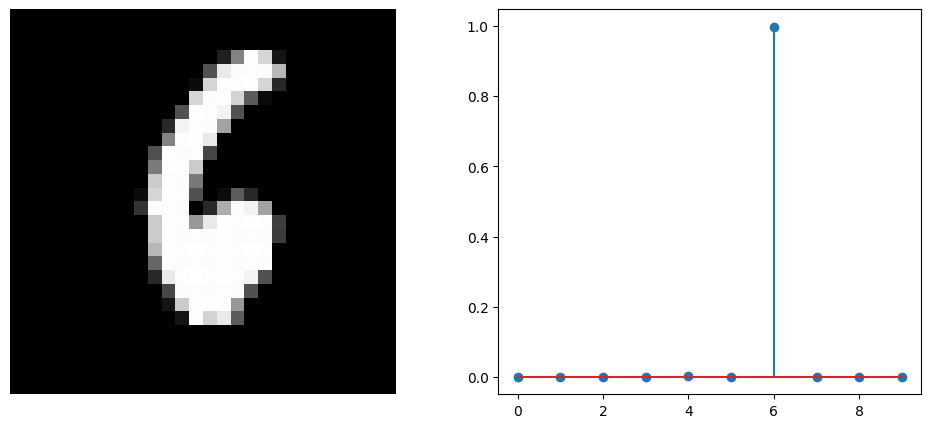

Prediction : 6
Probability : [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# MNIST 데이터셋 로딩
mnist = tf.keras.datasets.mnist
(train_x, train_y), (test_x, test_y) = mnist.load_data()

# 픽셀 값을 0~1 범위로 정규화
train_x, test_x = train_x / 255.0, test_x / 255.0


# Reshape the data for CNN input (batch, height, width, channels)
train_x = train_x.reshape((train_x.shape[0], 28, 28, 1))
test_x = test_x.reshape((test_x.shape[0], 28, 28, 1))

# input layer
input_h = 28               # input height
input_w = 28               # input width
input_ch = 1               # input channel (Grayscale)

# 1st convolution layer
k1_h = 3                   # kernel height
k1_w = 3                   # kernel width
k1_ch = 32                 # output channels (filters)
p1_h = 2                   # pool height
p1_w = 2                   # pool width
# output shape after pool: (None, 14, 14, 32)

# 2nd convolution layer
k2_h = 3
k2_w = 3
k2_ch = 64
p2_h = 2
p2_w = 2
# output shape after pool: (None, 7, 7, 64)

# Fully connected layer input size: flatten the features
conv_result_size = 7 * 7 * 64

n_hidden = 100             # hidden layer units
n_output = 10              # MNIST: 10 classes (0~9)


# Kernel size : [kernel_height, kernel_width, input_ch, output_ch]
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

weights = {
    'conv1': tf.Variable(tf.random.normal([3, 3, 1, 32], stddev=0.1)),     # 3x3 커널, 입력채널 1, 출력채널 32
    'conv2': tf.Variable(tf.random.normal([3, 3, 32, 64], stddev=0.1)),    # 3x3 커널, 입력채널 32, 출력채널 64
    'hidden': tf.Variable(tf.random.normal([7 * 7 * 64, 100], stddev=0.1)),# conv2 결과를 flatten한 후 100개의 노드
    'output': tf.Variable(tf.random.normal([100, 10], stddev=0.1))         # hidden → output layer (10 classes)
}

biases = {
    'conv1': tf.Variable(tf.random.normal([32], stddev=0.1)),   # conv1 출력 채널 수
    'conv2': tf.Variable(tf.random.normal([64], stddev=0.1)),   # conv2 출력 채널 수
    'hidden': tf.Variable(tf.random.normal([100], stddev=0.1)), # hidden layer 노드 수
    'output': tf.Variable(tf.random.normal([10], stddev=0.1))   # output layer 클래스 수
}
x = tf.placeholder(shape=[None, input_h, input_w, input_ch], dtype=tf.float32)
y = tf.placeholder(shape=[None, n_output], dtype=tf.float32)

def net(x, weights, biases):
    # 1st convolution layer: SAME padding
    conv1 = tf.nn.conv2d(x, weights['conv1'], strides=[1, 1, 1, 1], padding='SAME')
    conv1 = tf.nn.relu(tf.add(conv1, biases['conv1']))
    maxp1 = tf.nn.max_pool(conv1, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='SAME')

    # 2nd convolution layer: SAME padding
    conv2 = tf.nn.conv2d(maxp1, weights['conv2'], strides=[1, 1, 1, 1], padding='SAME')
    conv2 = tf.nn.relu(tf.add(conv2, biases['conv2']))
    maxp2 = tf.nn.max_pool(conv2, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='SAME')

    # flatten for fully connected layer
    maxp2_flatten = tf.reshape(maxp2, [-1, 7 * 7 * 64])  # SAME이면 출력 shape = (7, 7, 64)

    # Fully connected layer
    hidden = tf.add(tf.matmul(maxp2_flatten, weights['hidden']), biases['hidden'])
    hidden = tf.nn.relu(hidden)

    # Output layer
    output = tf.add(tf.matmul(hidden, weights['output']), biases['output'])

    return output


LR = 0.0001
pred = net(x, weights, biases)
loss = tf.nn.softmax_cross_entropy_with_logits(logits=pred, labels=y)           #내부적으로 계산 후 비교 y는 one hot vector
loss = tf.reduce_mean(loss)

optm = tf.train.AdamOptimizer(learning_rate=LR).minimize(loss)


n_batch = 50
n_iter = 2500
n_prt = 250

sess = tf.Session()
sess.run(tf.global_variables_initializer())

loss_record_train = []
loss_record_test = []
for epoch in range(n_iter):
    # train_x, train_y = mnist.train.next_batch(n_batch)
    # train_x = np.reshape(train_x, (-1, 28, 28, 1))
    # # train_x = np.reshape(train_x, (n_batch, input_h, input_w, input_ch))
    # sess.run(optm, feed_dict={x:train_x, y:train_y})

    # Get a random batch of training data
    batch_indices = np.random.choice(train_x.shape[0], size=n_batch, replace=False)
    batch_x = train_x[batch_indices]
    batch_y = train_y[batch_indices]

    batch_x = np.reshape(batch_x, (-1, 28, 28, 1))
    # batch_x = np.reshape(batch_x, (n_batch, input_h, input_w, input_ch))
    # Convert labels to one-hot encoding if necessary
    batch_y = tf.keras.utils.to_categorical(batch_y, num_classes=10)  # Adjust num_classes if needed

    sess.run(optm, feed_dict={x:batch_x, y:batch_y})

    if epoch % n_prt == 0:
        # test_x, test_y = mnist.test.next_batch(n_batch)
        # test_x = test_x.reshape((n_batch, input_h, input_w, input_ch))
        # c1 = sess.run(loss, feed_dict={x:train_x, y:train_y})
        # c2 = sess.run(loss, feed_dict={x:test_x, y:test_y})

        # Get a random batch of test data
        test_batch_indices = np.random.choice(test_x.shape[0], size=n_batch, replace=False)
        test_batch_x = test_x[test_batch_indices]
        test_batch_y = test_y[test_batch_indices]

        test_batch_x = test_batch_x.reshape((n_batch, input_h, input_w, input_ch))
        # Convert labels to one-hot encoding if necessary
        test_batch_y = tf.keras.utils.to_categorical(test_batch_y, num_classes=10)  # Adjust num_classes if needed
        c1 = sess.run(loss, feed_dict={x: batch_x, y: batch_y})
        c2 = sess.run(loss, feed_dict={x: test_batch_x, y: test_batch_y})

        loss_record_train.append(c1)
        loss_record_test.append(c2)
        print("Iter : {}".format(epoch))
        print("Train Loss : {}".format(c1))
        print("Cost : {}".format(c2))

plt.figure(figsize = (10,8))
plt.plot(np.arange(len(loss_record_train))*n_prt, loss_record_train, 'r', label = 'Train')
plt.plot(np.arange(len(loss_record_test))*n_prt, loss_record_test, 'b', label = 'Test')
plt.xlabel('Iteration', fontsize = 15)
plt.ylabel('Loss', fontsize = 15)
plt.legend(fontsize = 12)
plt.ylim([0, np.max(loss_record_train)])
plt.show()


# 정확도 평가
test_batch_indices = np.random.choice(test_x.shape[0], size=n_batch, replace=False)
test_batch_x = test_x[test_batch_indices]
test_batch_y = test_y[test_batch_indices]
test_batch_x = test_batch_x.reshape((n_batch, input_h, input_w, input_ch))
test_batch_y = tf.keras.utils.to_categorical(test_batch_y, num_classes=10)

my_pred = sess.run(pred, feed_dict={x: test_batch_x})
my_pred = np.argmax(my_pred, axis=1)
labels = np.argmax(test_batch_y, axis=1)
accr = np.mean(np.equal(my_pred, labels))
print("Accuracy : {}%".format(accr * 100))

# 시각화
n_batch = 1
test_batch_indices = np.random.choice(test_x.shape[0], size=n_batch, replace=False)
test_batch_x = test_x[test_batch_indices]
test_batch_y = test_y[test_batch_indices]
test_batch_x = test_batch_x.reshape((n_batch, input_h, input_w, input_ch))
test_batch_y = tf.keras.utils.to_categorical(test_batch_y, num_classes=10)

logits = sess.run(tf.nn.softmax(pred), feed_dict={x: test_batch_x})
predict = np.argmax(logits)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_batch_x.reshape(28, 28), 'gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.stem(logits.ravel())
plt.show()

np.set_printoptions(precision=2, suppress=True)
print('Prediction : {}'.format(predict))
print('Probability : {}'.format(logits.ravel()))
